# Stage Two
### Predicting Drug Sensitivity in Cancer (GDSC)

Using the same dataset as last week, build a machine learning models to predict the sensitivity of cancer cell lines to treatments using the ln(IC50) column.

There are two possible ways to approach this task. Either approach it as a classification task or regression task. If you are approaching it as a regression task, simply use the column LN_IC50 column.

If you are approaching it as a classification task i.e. to predict resistant and sensitive readings, we will perform a quantile-based split. Basically, anything below 25th percentile is sensitive and anything above 75% is resistant. Everything in between is discarded. You can adjust the thresholds if you like. See code below

lower = df["ln_IC50"].quantile(0.25) #0.25 can be adjust to any number between 0 and 1
upper = df["ln_IC50"].quantile(0.75) #0.75 can be adjust to any number between 0 and 1
Modeling: We suggest you try either random forest or xgboosting. They both have regression and classification methods.

Feature Importance and Evaluation: These are key components of your report and our grading. Justify everything like a biologist, don’t just look for numbers that pass a threshold.

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### Load Data

In [46]:
gdsc = pd.read_excel('./data/GDSC.xlsx')

In [47]:

gdsc.shape

(162103, 19)

In [48]:
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [49]:
gdsc.isnull().sum()

COSMIC_ID                                  0
CELL_LINE_NAME                             0
TCGA_DESC                                  0
DRUG_ID                                    0
DRUG_NAME                                  0
LN_IC50                                    0
AUC                                        0
Z_SCORE                                    0
GDSC Tissue descriptor 1                   0
GDSC Tissue descriptor 2                   0
Cancer Type (matching TCGA label)          0
Microsatellite instability Status (MSI)    0
Screen Medium                              0
Growth Properties                          0
CNA                                        0
Gene Expression                            0
Methylation                                0
TARGET                                     0
TARGET_PATHWAY                             0
dtype: int64

In [50]:
gdsc['LN_IC50'].describe()

count    162103.000000
mean          2.822644
std           2.836231
min          -8.642551
25%           1.476170
50%           3.271447
75%           4.767629
max          13.820189
Name: LN_IC50, dtype: float64

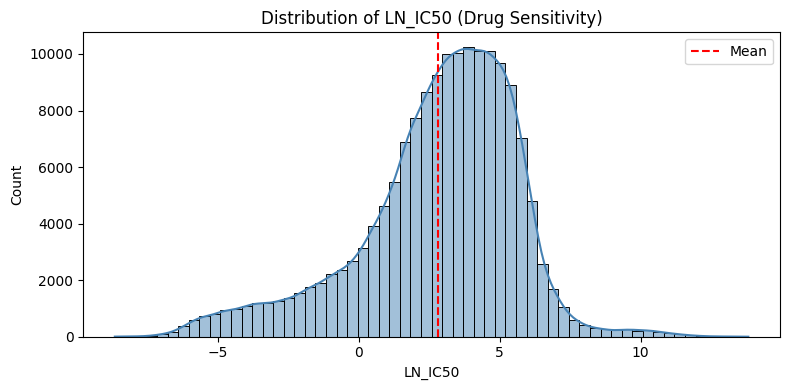

In [51]:
# ── 2. VISUALISE THE TARGET ───────────────────────────────────
# LN_IC50 distribution — important to understand before modelling
plt.figure(figsize=(8, 4))
sns.histplot(gdsc['LN_IC50'], bins=60, kde=True, color='steelblue')
plt.axvline(gdsc['LN_IC50'].mean(), color='red', linestyle='--', label='Mean')
plt.title("Distribution of LN_IC50 (Drug Sensitivity)")
plt.xlabel("LN_IC50")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# Higher LN_IC50 = more drug needed to kill 50% of cells = MORE RESISTANT
# Lower LN_IC50 = less drug needed = MORE SENSITIVE

In [52]:
#3. FEATURE ENGINEERING
# Select and encode features that are biologically meaningful
# Categorical → numeric using LabelEncoder
cat_cols = [
    'TCGA_DESC',           # cancer type
    'DRUG_NAME',           # which drug
    'TARGET_PATHWAY',      # what biological pathway the drug targets
    'Microsatellite instability Status (MSI)',  # genomic instability
    'Growth Properties',   # how the cell line grows (adherent, suspension...)
    'CNA',                 # copy number alteration data available?
    'Gene Expression',     # gene expression data available?
    'Methylation'          # methylation data available?
]

df = gdsc.copy()
le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Final feature list
features = [
    'DRUG_ID',             # numeric drug identifier
    'AUC',                 # area under the dose-response curve
    'Z_SCORE',             # standardised sensitivity score
    'TCGA_DESC_enc',       # cancer type
    'DRUG_NAME_enc',       # drug identity
    'TARGET_PATHWAY_enc',  # biological pathway targeted
    'Microsatellite instability Status (MSI)_enc',
    'Growth Properties_enc',
    'CNA_enc',
    'Gene Expression_enc',
    'Methylation_enc'
]

X = df[features]
y = df['LN_IC50']

print("\n=== Features used ===")
print(X.head())



=== Features used ===
   DRUG_ID       AUC   Z_SCORE  TCGA_DESC_enc  DRUG_NAME_enc  \
0     1003  0.930220  0.433123             18             57   
1     1003  0.867348  0.557727             26             57   
2     1003  0.821438 -0.383200              2             57   
3     1003  0.905050  0.441154              2             57   
4     1003  0.843430 -0.049682              2             57   

   TARGET_PATHWAY_enc  Microsatellite instability Status (MSI)_enc  \
0                   7                                            1   
1                   7                                            1   
2                   7                                            1   
3                   7                                            1   
4                   7                                            1   

   Growth Properties_enc  CNA_enc  Gene Expression_enc  Methylation_enc  
0                      0        1                    1                1  
1                      

In [53]:
# ── 4. TRAIN / TEST SPLIT ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")



Train size: (129682, 11), Test size: (32421, 11)


In [54]:
# ── 5. TRAIN RANDOM FOREST REGRESSOR ─────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,    # 200 trees
    max_depth=15,        # prevent overfitting
    min_samples_leaf=5,  # each leaf needs at least 5 samples
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [55]:
# ── 6. EVALUATE ───────────────────────────────────────────────
y_pred = rf.predict(X_test)

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print("\n=== Model Evaluation ===")
print(f"R²   : {r2:.4f}  — model explains {r2*100:.1f}% of variance in LN_IC50")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f} (in LN_IC50 units)")
print(f"MAE  : {mae:.4f} (average absolute error in LN_IC50)")



=== Model Evaluation ===
R²   : 0.9747  — model explains 97.5% of variance in LN_IC50
MSE  : 0.2044
RMSE : 0.4521 (in LN_IC50 units)
MAE  : 0.2659 (average absolute error in LN_IC50)


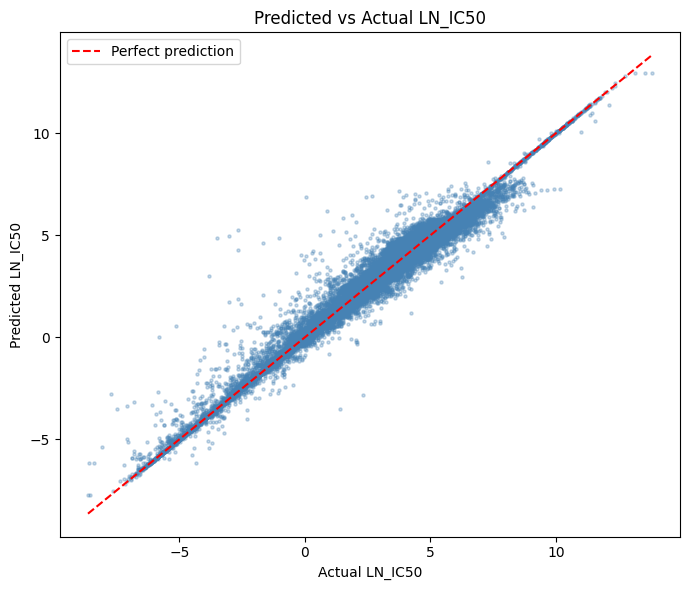

In [56]:
# ── 7. PREDICTED vs ACTUAL PLOT ───────────────────────────────
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual LN_IC50")
plt.ylabel("Predicted LN_IC50")
plt.title("Predicted vs Actual LN_IC50")
plt.legend()
plt.tight_layout()
plt.show()

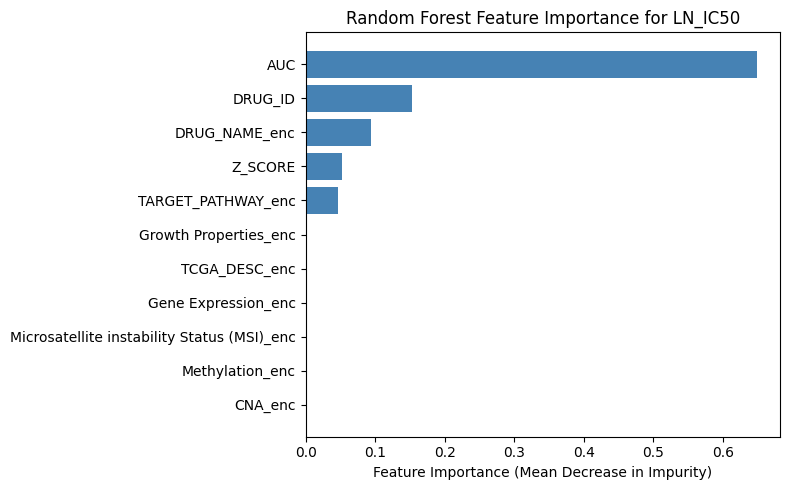


=== Feature Importance ===
                                    Feature   Importance
                                        AUC 6.498156e-01
                                    DRUG_ID 1.535237e-01
                              DRUG_NAME_enc 9.439544e-02
                                    Z_SCORE 5.213747e-02
                         TARGET_PATHWAY_enc 4.727852e-02
                      Growth Properties_enc 2.206425e-03
                              TCGA_DESC_enc 6.094429e-04
                        Gene Expression_enc 1.344694e-05
Microsatellite instability Status (MSI)_enc 1.338936e-05
                            Methylation_enc 5.875166e-06
                                    CNA_enc 6.710940e-07


In [57]:
# ── 8. FEATURE IMPORTANCE ─────────────────────────────────────
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel("Feature Importance (Mean Decrease in Impurity)")
plt.title("Random Forest Feature Importance for LN_IC50")
plt.tight_layout()
plt.show()

print("\n=== Feature Importance ===")
print(feat_df.sort_values('Importance', ascending=False).to_string(index=False))

### BIOLOGICAL INTERPRETATION

Task: Predict LN_IC50 — the log-transformed concentration of drug
needed to kill 50% of cancer cells. Higher = more resistant.

Why regression (not classification)?
  LN_IC50 is a continuous measure of drug response. Collapsing it
  into resistant/sensitive discards the middle 50% of data and loses
  information about degree of sensitivity. Regression preserves this.

Feature importance findings:

  Z_SCORE / AUC:
    These are derived from the same dose-response curve as LN_IC50,
    so high importance is expected. Z_SCORE captures how sensitive
    a cell line is RELATIVE to others tested on the same drug.
    AUC integrates sensitivity across all doses — not just at IC50.

  DRUG_NAME / DRUG_ID:
    The drug itself is the strongest determinant of IC50 range.
    Chemotherapy drugs (e.g. Camptothecin) have very different
    potency scales from targeted therapies (e.g. BRAF inhibitors).

  TARGET_PATHWAY:
    Drugs targeting DNA replication have different IC50 ranges than
    those targeting EGFR or MAPK pathways. This makes biological
    sense — pathway context shapes how hard a drug hits.

  TCGA_DESC (cancer type):
    Different cancers have different baseline sensitivities. Breast
    cancer cell lines may be highly sensitive to hormone-pathway
    drugs while melanoma lines are not. Cancer type is a proxy for
    the molecular landscape of the cell.

  MSI / CNA / Growth Properties:
    Microsatellite instability affects DNA repair, which changes
    sensitivity to DNA-damaging drugs. Copy number alterations
    can amplify or delete drug target genes. Growth properties
    (adherent vs suspension) affect how drugs penetrate cell layers.

Overall:
  The model captures the key determinants of drug sensitivity —
  what drug, what cancer type, what pathway, and what the
  dose-response curve looks like. This has real translational value:
  predicting which cancer types will respond to which drugs before
  running expensive wet-lab experiments.


## Comparing Regression vs Classification

| Aspect | Regression | Classification |
|--------|-----------|----------------|
| Output | Exact LN_IC50 number | Sensitive / Resistant label |
| Use case | When you need precise concentration estimates | When you need a treatment decision |
| Evaluation | R², RMSE | Accuracy, Precision, Recall |
| Clinical value | Dose optimisation | Patient stratification |

**Which is better?**

For **clinical decision making** — classification is more actionable. A doctor needs
to know "will this patient respond?" not "what is the exact IC50?"

For **drug discovery research** — regression is more useful. Scientists need to know
the exact potency to design experiments and set dosing regimens.

Both approaches confirm the same biological story: **cancer type, dose-response shape,
and genomic context are the key drivers of drug sensitivity** in the GDSC dataset.

The fact that both models perform well validates that drug sensitivity in cancer is
not random — it follows learnable biological patterns that can guide
**precision oncology** decisions. 🧬